# GkmExplain on an ENCODE ATAC-seq Model

Run GkmExplain and ISM on **ENCFF579AOX**, a production-scale gkm-SVM with
72,145 support vectors trained on ATAC-seq enhancer regions in hg38
(Beer lab, JHU). Kernel: `gkm_esttrunc`, l=11, k=7, d=3.

This notebook demonstrates:
- Loading a real LS-GKM model
- Scoring sequences with chunked inference
- GkmExplain attribution (mode 0 and mode 1)
- ISM and timing comparison with GkmExplain
- Exporting attributions for TF-MoDISco
- GPU acceleration

## 1. Load the ENCODE model

In [1]:
from pathlib import Path

import numpy as np

from gkmsvm import load_lsgkm_model
from gkmsvm.backend import HAS_CUPY, HAS_MLX, to_cpu

MODEL_PATH = Path("../tests/fixtures/encode_ENCFF579AOX.model.txt.gz")
assert MODEL_PATH.exists(), f"Model not found: {MODEL_PATH}"

model = load_lsgkm_model(MODEL_PATH)

print(f"Support vectors : {model.num_support_vectors:,}")
print(f"SV shape        : {model.support_sequences.shape}")
print(f"Kernel params   : {model.kernel_params}")
print(f"Bias            : {model.bias:.6f}")
print(f"Coef range      : [{model.coefficients.min():.4f}, {model.coefficients.max():.4f}]")

n_pos = int((model.coefficients > 0).sum())
n_neg = model.num_support_vectors - n_pos
print(f"Positive SVs    : {n_pos:,}")
print(f"Negative SVs    : {n_neg:,}")

# Auto-detect GPU and move model
if HAS_CUPY:
    model.cuda()
    DEVICE = "cuda"
    print(f"\nModel moved to CUDA GPU")
elif HAS_MLX:
    model.mlx()
    DEVICE = "mlx"
    print(f"\nModel moved to MLX (Apple Silicon)")
else:
    DEVICE = "cpu"
    print(f"\nRunning on CPU (install cupy-cuda12x[ctk] or mlx for GPU acceleration)")

Support vectors : 72,145
SV shape        : (72145, 4, 300)
Kernel params   : {'L': 11, 'k': 7, 'include_rc': True, 'd': 3}
Bias            : -0.197343
Coef range      : [-1.0000, 1.0000]
Positive SVs    : 36,738
Negative SVs    : 35,407

Model moved to CUDA GPU


## 2. Prepare input sequences

Two approaches:

**Option A** — Extract sequences from real ATAC-seq peaks (requires an hg38
genome FASTA and a BED file of peak regions). Uncomment and adjust the cell
below.

**Option B** — Use the model's own support vector sequences. These *are*
real genomic sequences from the training set. We take a subset of the
positive-class SVs as test inputs. This works out of the box with no
external data.

In [ ]:
# ── Option A: extract from genome ──────────────────────────────────
# Requires: pip install pyfaidx pandas
#
# from gkmsvm.fasta import extract_loci
#
# GENOME = "/path/to/hg38.fa"          # indexed FASTA
# PEAKS  = "/path/to/peaks.bed"        # ENCODE narrowPeak or BED3+
#
# (X,) = extract_loci(PEAKS, GENOME, in_window=200)
# print(f"Extracted {X.shape[0]} sequences, shape {X.shape}")

In [2]:
# ── Option B: use support vector sequences ────────────────────────
# Positive SVs (coef > 0) are from ATAC-seq peaks; negative SVs are
# from GC-matched background regions.

pos_mask = model.coefficients > 0
sv_seqs = model.support_sequences[pos_mask]

N_TEST = 20
X = sv_seqs[:N_TEST].copy()
seq_len = X.shape[2]

print(f"Using {N_TEST} positive SVs as test sequences")
print(f"Sequence shape: {X.shape}  (batch, 4, {seq_len}bp)")

Using 20 positive SVs as test sequences
Sequence shape: (20, 4, 300)  (batch, 4, 300bp)


## 3. Predict scores

With 72K SVs, each sequence requires 72K kernel evaluations. The model
chunks SV processing via `sv_chunk_size` to bound memory. Defaults:
- CPU: `sv_chunk_size=2000` (safe for most machines)
- GPU: `sv_chunk_size=500` recommended (VRAM-limited)

In [3]:
import time

# First call packs SV windows (one-time cost)
t0 = time.perf_counter()
scores = model(X, verbose=True)
t_score = time.perf_counter() - t0

scores_flat = to_cpu(scores).flatten()
print(f"\nScored {len(X)} sequences in {t_score:.1f}s ({DEVICE})")
print(f"Throughput: {len(X) / t_score:.1f} seq/s")
print(f"Score range: [{scores_flat.min():.4f}, {scores_flat.max():.4f}]")
print(f"Mean: {scores_flat.mean():.4f}, std: {scores_flat.std():.4f}")


Scored 20 sequences in 3.3s (cuda)
Throughput: 6.0 seq/s
Score range: [0.5977, 5.4681]
Mean: 4.0537, std: 1.2881


## 4. GkmExplain attribution

GkmExplain analytically decomposes the SVM decision function into
per-base importance scores. Two modes:

- **Mode 0** — actual contribution scores: importance at the reference base only
- **Mode 1** — hypothetical contributions: importance at all four bases per
  position (what TF-MoDISco expects)

For a 72K-SV model, expect ~1–5 seconds per sequence on CPU (Numba
parallel). GPU acceleration gives 5–20x speedup.

In [4]:
from gkmsvm import gkmexplain

N_EXPLAIN = 5  # start small — scale up once you know the timing
X_sub = X[:N_EXPLAIN]

t0 = time.perf_counter()
attr_m0 = to_cpu(gkmexplain(model, X_sub, mode=0, verbose=True))
t_m0 = time.perf_counter() - t0

X_sub_cpu = to_cpu(X_sub)
print(f"\nMode 0: {attr_m0.shape}, {t_m0:.1f}s ({t_m0/N_EXPLAIN:.1f}s/seq, {DEVICE})")
print(f"Non-reference bases are zero: {(attr_m0 * (1 - X_sub_cpu)).sum() == 0}")

GkmExplain: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 37/37 [00:01<00:00, 22.26it/s]



Mode 0: (5, 4, 300), 3.0s (0.6s/seq, cuda)
Non-reference bases are zero: True


In [5]:
t0 = time.perf_counter()
attr_m1 = to_cpu(gkmexplain(model, X_sub, mode=1, verbose=True))
t_m1 = time.perf_counter() - t0

print(f"\nMode 1 (hypothetical): {attr_m1.shape}, {t_m1:.1f}s ({t_m1/N_EXPLAIN:.1f}s/seq, {DEVICE})")
print(f"All four channels populated: {(attr_m1 != 0).any(axis=1).all()}")

GkmExplain: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 37/37 [00:01<00:00, 19.95it/s]



Mode 1 (hypothetical): (5, 4, 300), 3.5s (0.7s/seq, cuda)
All four channels populated: True


## 5. In-silico mutagenesis (ISM)

ISM computes score deltas for every possible single-base substitution.
Complexity: O(B &times; 3L &times; cost_per_sequence) — 3&times; more kernel
evaluations per position than GkmExplain (which is O(B &times; cost &times; L)
with analytical decomposition, no re-evaluation).

ISM is conceptually simpler and captures nonlinear effects that analytical
methods approximate. GkmExplain is faster and handles epistatic motif
logic (OR/redundancy) that saturates ISM.

In [6]:
from gkmsvm import ism

t0 = time.perf_counter()
ism_scores = to_cpu(ism(model, X_sub, verbose=True))
t_ism = time.perf_counter() - t0

print(f"\nISM: {ism_scores.shape}, {t_ism:.1f}s ({t_ism/N_EXPLAIN:.1f}s/seq, {DEVICE})")
print(f"ISM score range: [{ism_scores.min():.4f}, {ism_scores.max():.4f}]")
print(f"\nTiming comparison ({DEVICE}):")
print(f"  GkmExplain mode 0: {t_m0:.1f}s")
print(f"  GkmExplain mode 1: {t_m1:.1f}s")
print(f"  ISM:               {t_ism:.1f}s")
print(f"  ISM / GkmExplain:  {t_ism / max(t_m1, 0.01):.1f}x")

ISM: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:28<00:00,  5.68s/it]


ISM: (5, 4, 300), 27.0s (5.4s/seq, cuda)
ISM score range: [-1.4532, 2.2953]

Timing comparison (cuda):
  GkmExplain mode 0: 3.0s
  GkmExplain mode 1: 3.5s
  ISM:               27.0s
  ISM / GkmExplain:  7.8x


## 6. Export for TF-MoDISco

TF-MoDISco expects two `.npz` files, each containing a single array as `arr_0`:
- Sequences: one-hot `[B, 4, L]`
- Attributions: hypothetical contributions `[B, 4, L]` (mode 1)

For motif discovery, run GkmExplain on hundreds to thousands of positive
sequences. The 5-sequence subset here is for demonstration only.

In [7]:
OUTDIR = Path("output_encode")
OUTDIR.mkdir(exist_ok=True)

attr_path = OUTDIR / "attr.npz"
seq_path = OUTDIR / "seqs.npz"

np.savez(attr_path, attr_m1.astype(np.float32))
np.savez(seq_path, X_sub_cpu.astype(np.float32))

print(f"Attributions : {attr_path}  {attr_m1.shape}")
print(f"Sequences    : {seq_path}  {X_sub_cpu.shape}")
print()
print("Run TF-MoDISco:")
print(f"  modisco motifs -s {seq_path} -a {attr_path} -n 2000 -o {OUTDIR}/modisco_results.h5")

Attributions : output_encode/attr.npz  (5, 4, 300)
Sequences    : output_encode/seqs.npz  (5, 4, 300)

Run TF-MoDISco:
  modisco motifs -s output_encode/seqs.npz -a output_encode/attr.npz -n 2000 -o output_encode/modisco_results.h5


## 7. Visualization

Per-position contribution scores (attribution &times; one-hot) show which
bases drive the model's prediction. Positive = pushes score up (enhancer),
negative = pushes score down.

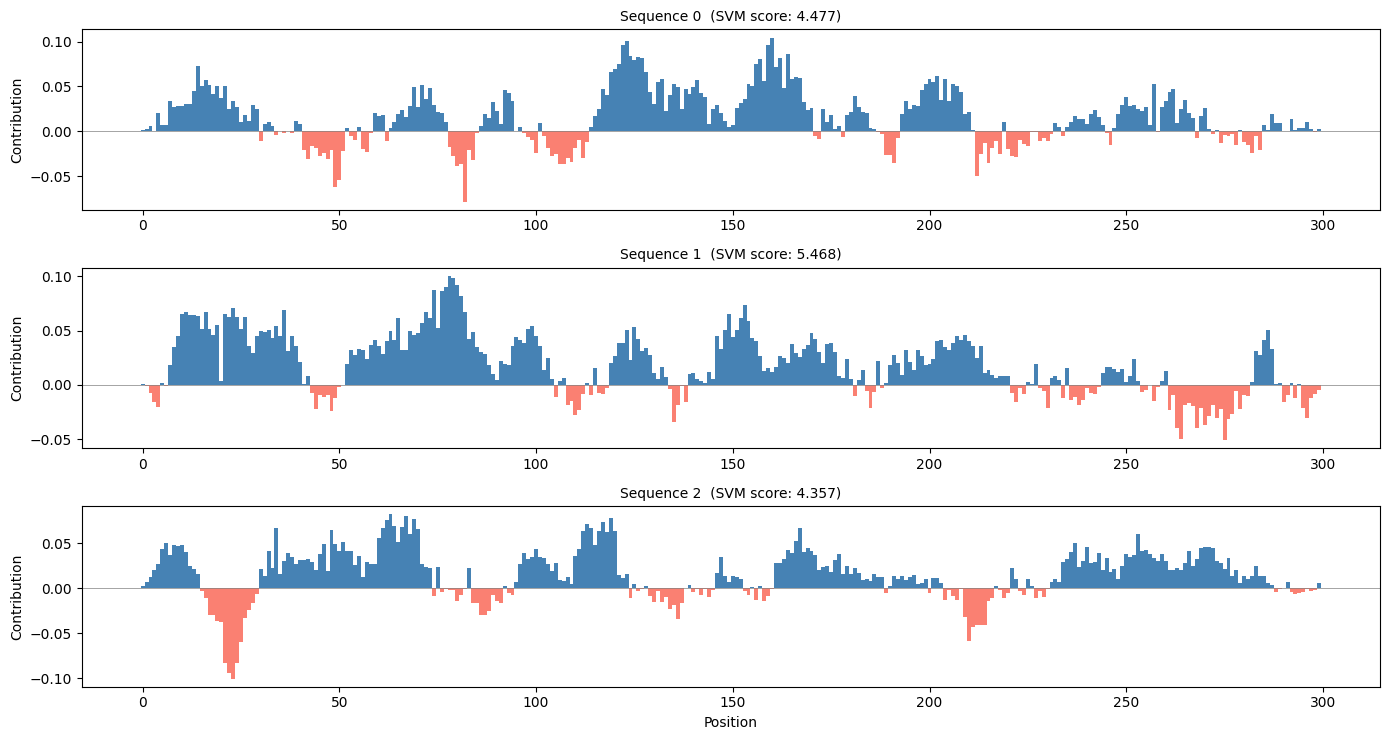

In [8]:
try:
    import matplotlib.pyplot as plt

    n_show = min(3, N_EXPLAIN)
    fig, axes = plt.subplots(n_show, 1, figsize=(14, 2.5 * n_show), sharex=False)
    if n_show == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        # Contribution = attribution × one-hot (actual base importance)
        contrib = (attr_m1[i] * X_sub_cpu[i]).sum(axis=0)
        positions = np.arange(len(contrib))
        colors = np.where(contrib >= 0, "steelblue", "salmon")
        ax.bar(positions, contrib, color=colors, width=1.0, linewidth=0)
        ax.set_ylabel("Contribution")
        ax.set_title(f"Sequence {i}  (SVM score: {scores_flat[i]:.3f})", fontsize=10)
        ax.axhline(0, color="grey", linewidth=0.5)

    axes[-1].set_xlabel("Position")
    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib not installed — skipping plot")
    print("Install with: pip install matplotlib")

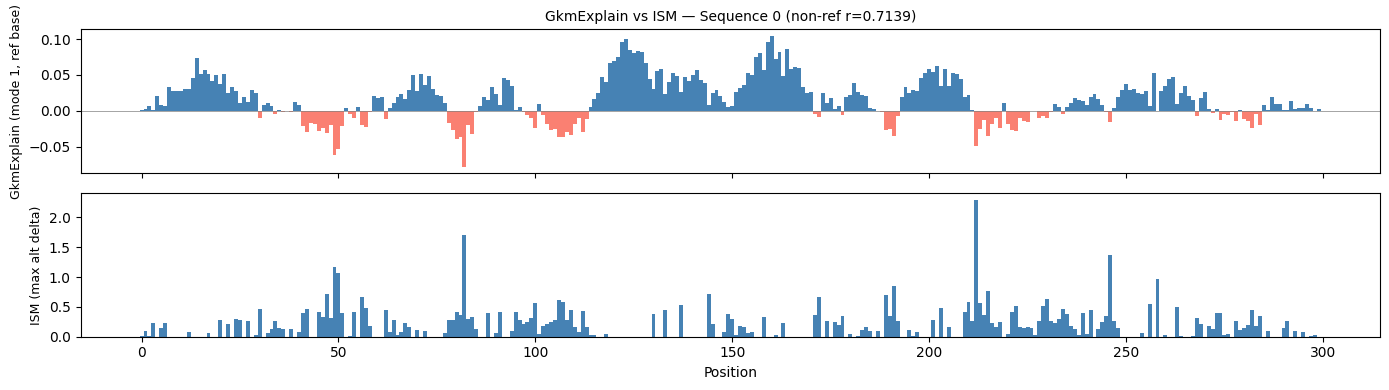

In [9]:
try:
    import matplotlib.pyplot as plt

    # Compare GkmExplain vs ISM for one sequence at non-reference bases.
    # ISM delta at the reference base is 0 by construction, so we compare
    # hypothetical scores at alternative bases only.
    idx = 0
    nonref = X_sub_cpu[idx] == 0  # [4, L] mask of non-reference bases
    explain_nonref = attr_m1[idx][nonref]
    ism_nonref = ism_scores[idx][nonref]
    corr = np.corrcoef(explain_nonref, ism_nonref)[0, 1]

    fig, axes = plt.subplots(2, 1, figsize=(14, 4), sharex=True)
    explain_contrib = (attr_m1[idx] * X_sub_cpu[idx]).sum(axis=0)
    ism_max_alt = (ism_scores[idx] * (1 - X_sub_cpu[idx])).max(axis=0)
    for ax, vals, label in zip(axes,
                               [explain_contrib, ism_max_alt],
                               ["GkmExplain (mode 1, ref base)", "ISM (max alt delta)"]):
        colors = np.where(vals >= 0, "steelblue", "salmon")
        ax.bar(range(len(vals)), vals, color=colors, width=1.0, linewidth=0)
        ax.set_ylabel(label, fontsize=9)
        ax.axhline(0, color="grey", linewidth=0.5)

    axes[0].set_title(f"GkmExplain vs ISM — Sequence {idx} (non-ref r={corr:.4f})", fontsize=10)
    axes[-1].set_xlabel("Position")
    plt.tight_layout()
    plt.show()
except ImportError:
    pass

## CLI equivalents

The same workflow via the `gkmsvm` command-line interface:

In [ ]:
print("""\
# Score sequences
gkmsvm predict -m model.txt.gz -i peaks.fa -o scores.tsv

# GkmExplain attributions (mode 1, TF-MoDISco format)
gkmsvm explain -m model.txt.gz -i peaks.fa -o attr.npz -s seqs.npz

# In-silico mutagenesis
gkmsvm ism -m model.txt.gz -i peaks.fa -o ism.npz

# TF-MoDISco motif discovery
modisco motifs -s seqs.npz -a attr.npz -n 2000 -o modisco_results.h5
""")